# Low Chin Tone Detection from EMG Signal - Version 2

This version loads raw EDF signals directly without normalization.
- Loads EDF files directly using modules from sleep_stage
- Processes raw EMG signals without normalization
- Divides 30-second epochs into 10 segments of 3 seconds each
- Calculates energy for each segment
- Determines threshold based on REM stage statistics
- Generates XML output with segment-wise RMS values

In [25]:
import sys
import os
sys.path.append('/home/honeynaps/data/shared/integrate/sleep_stage')

import random
import torch
import torch.nn as nn
import numpy as np
import pickle
import natsort
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import timedelta, datetime
import datetime as dt

# Import sleep_stage modules
from sleep_stage.modules.iofiles import edf as edf_io
from sleep_stage.modules.preprocessing import prep_psg_signal, prep_psg_signal_with_missing
from sleep_stage.prep_window_wise import epoching_from_time
from sleep_stage.utils.tools import str2bool

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(5)
np.random.seed(5)
random.seed(5)

In [26]:
def load_edf_raw(edf_path, fs=50):
    """
    Load EDF file and extract raw signals without normalization
    Based on sleep_score.py and SleepFinal.py
    
    Args:
        edf_path: Path to EDF file
        fs: Sampling frequency (default: 50Hz)
    
    Returns:
        sigs: Dictionary of signals
        base_time: Recording start time
        X: Epoched data (n_epochs, n_samples, n_channels)
    """
    # Load EDF using edf_io module
    edf, n_missing_ch = edf_io.load(
        path       = edf_path, 
        preload    = True, 
        resample   = fs, 
        preset     = "STAGENET", 
        exclude    = True,
        missing_ch = 'raise'
    )
    
    base_time = edf.info['meas_date'].replace(tzinfo=None)
    data = edf.get_data()
    
    # Channel mapping (from sleep_score.py)
    SID_MAP = { 
        'F3-':'F3_2', 'F4-':'F4_1', 'C3-':'C3_2', 'C4-':'C4_1', 
        'O1-':'O1_2', 'O2-':'O2_1', 
        'LOC':'LOC' , 'ROC':'ROC', 
        'EMG':'CHIN'
    }
    
    sigs = {}
    for i in range(len(edf.ch_names)):
        name = edf.ch_names[i]
        if name in SID_MAP:
            sigs[SID_MAP[name]] = data[i]
        else:
            sigs[SID_MAP[name[:3]]] = data[i]
    
    # Channel sequence (from SleepFinal.py)
    SID_SEQs = ['F3_2', 'F4_1', 'C3_2', 'C4_1', 'O1_2', 'O2_1', 'LOC', 'ROC', 'CHIN']
    ordered_data = [None for _ in range(len(SID_SEQs))]
    
    for sid, sig in sigs.items():
        if sid in SID_SEQs:
            i = SID_SEQs.index(sid)
            ordered_data[i] = sig
    
    # Check for missing channels
    missing_channels = [i for i in range(9) if ordered_data[i] is None]
    ordered_data = [d for d in ordered_data if d is not None]
    ordered_data = np.array(ordered_data)
    
    # Preprocessing (minimal - just epoching)
    # if len(missing_channels) > 0:
    #     processed_data = prep_psg_signal_with_missing(ordered_data, transpose=True, fs=fs, missing_channels=missing_channels)
    # else:
    #     processed_data = prep_psg_signal(ordered_data, transpose=True, fs=fs, normalize=False)
    
    # Epoch the data
    X = epoching_from_time(ordered_data.T, base_time, base_time, sfreq=fs) # (n_epochs, n_samples, n_channels)

    # Calculate the median for each channel and subtract it
    medians = np.median(ordered_data, axis=1)
    for i in range(ordered_data.shape[0]):
        ordered_data[i] -= medians[i]

    return sigs, base_time, X, edf.ch_names

In [27]:
def calculate_emg_energy(emg_signal, segment_length=150):
    """
    Calculate energy for 3-second segments of EMG signal
    
    Args:
        emg_signal: EMG signal (1500 samples for 30 seconds at 50Hz)
        segment_length: Length of each segment (150 samples = 3 seconds at 50Hz)
    
    Returns:
        energy_values: Array of 10 energy values for each 3-second segment
    """
    energy_values = []
    
    for i in range(0, len(emg_signal), segment_length):
        segment = emg_signal[i:i+segment_length]
        if len(segment) == segment_length:
            # Calculate RMS energy
            energy = np.sqrt(np.mean(segment**2))
            energy_values.append(energy)
    
    return np.array(energy_values)

In [28]:
def load_sleep_stage_xml(xml_path):
    """
    Load sleep stage XML and return the first epoch onset time and labels
    
    Args:
        xml_path: Path to the SLEEP XML file
    
    Returns:
        first_epoch_onset: datetime object of the first epoch
        sleep_stages: List of sleep stage labels
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        sleep_stages = []
        first_epoch_onset = None
        
        # Parse all annotations to get sleep stages
        for i, annotation in enumerate(root.findall("annotation")):
            if i == 0:
                onset_text = annotation.find("onset").text
                first_epoch_onset = dt.datetime.strptime(onset_text, "%Y-%m-%dT%H:%M:%S.%f")
            
            description = annotation.find("description").text
            # Convert stage description to numeric label
            if 'W' in description:
                sleep_stages.append(0)
            elif "R" in description:
                sleep_stages.append(1)
            elif "1" in description:
                sleep_stages.append(2)
            elif "2" in description:
                sleep_stages.append(3)
            elif "3" in description:
                sleep_stages.append(4)
        
        return first_epoch_onset, sleep_stages
    except Exception as e:
        print(f"Error reading SLEEP XML {xml_path}: {e}")
        return None, []

In [29]:
def save_low_chin_xml(meas_date, y_all_epochs, sfreq, xml_save_path, 
                       description="LOW_CHIN_TONE", location="EEG-EMG", min_duration=1.0):
    """
    Save low chin tone events to XML file
    """
    # Find continuous periods of low chin tone
    diff_y = np.diff(np.concatenate([[0], y_all_epochs, [0]]))  
    start_points = np.where(diff_y == 1)[0]
    end_points = np.where(diff_y == -1)[0]

    root = ET.Element("annotationlist")
    
    # Add recording duration (but remove recording_start_time)
    recording_duration = len(y_all_epochs) / sfreq
    ET.SubElement(root, "recording_duration").text = f"{recording_duration:.6f}"

    event_count = 0
    for start_idx, end_idx in zip(start_points, end_points):
        start_sec = start_idx / sfreq
        end_sec = end_idx / sfreq
        duration = end_sec - start_sec

        # Only include events longer than minimum duration
        if duration < min_duration:
            continue

        # Calculate onset time relative to the first epoch onset
        onset_time = meas_date + timedelta(seconds=start_sec)

        annotation = ET.SubElement(root, "annotation")

        onset_elem = ET.SubElement(annotation, "onset")
        onset_elem.text = onset_time.strftime("%Y-%m-%dT%H:%M:%S.%f")

        duration_elem = ET.SubElement(annotation, "duration")
        duration_elem.text = f"{duration:.6f}"

        desc_elem = ET.SubElement(annotation, "description")
        desc_elem.text = description

        location_elem = ET.SubElement(annotation, "location")
        location_elem.text = location
        
        event_count += 1

    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ", level=0)

    with open(xml_save_path, "wb") as fp:
        fp.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
        tree.write(fp, encoding="UTF-8", xml_declaration=False)
    
    return event_count

In [ ]:
def save_low_chin_segments_xml(meas_date, epoch_data_list, sfreq, xml_save_path, 
                               segment_length=150, threshold=0.5):
    """
    Save 3-second segment annotations with RMS values to XML file
    """
    root = ET.Element("annotationlist")
    
    # Calculate total recording duration
    total_samples = len(epoch_data_list) * 1500  # 30 seconds per epoch
    recording_duration = total_samples / sfreq
    ET.SubElement(root, "recording_duration").text = f"{recording_duration:.6f}"
    
    event_count = 0
    
    # Process each epoch
    for epoch_idx, epoch_data in enumerate(epoch_data_list):
        # Calculate energy values for this epoch
        energy_values = calculate_emg_energy(epoch_data, segment_length)
        
        # Process each 3-second segment
        for seg_idx, energy in enumerate(energy_values):
            # Determine if low or high chin tone
            is_low_chin = energy < threshold
            type_label = "LOW" if is_low_chin else "HIGH"
            
            # Create description with TYPE_RMS format
            description = f"{type_label}_{energy:.4f}"
        
            # Calculate timing
            epoch_start_sec = epoch_idx * 30  # 30 seconds per epoch
            segment_start_sec = seg_idx * 3    # 3 seconds per segment
            total_start_sec = epoch_start_sec + segment_start_sec
            
            # Calculate onset time
            onset_time = meas_date + timedelta(seconds=total_start_sec)
            
            # Create annotation element
            annotation = ET.SubElement(root, "annotation")
            
            onset_elem = ET.SubElement(annotation, "onset")
            onset_elem.text = onset_time.strftime("%Y-%m-%dT%H:%M:%S.%f")
            
            duration_elem = ET.SubElement(annotation, "duration")
            duration_elem.text = "3.000000"  # Always 3 seconds
            
            desc_elem = ET.SubElement(annotation, "description")
            desc_elem.text = description
            
            location_elem = ET.SubElement(annotation, "location")
            location_elem.text = "EEG-EMG"
            
            event_count += 1
    
    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ", level=0)
    
    with open(xml_save_path, "wb") as fp:
        fp.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
        tree.write(fp, encoding="UTF-8", xml_declaration=False)
    
    return event_count

In [31]:
# Configuration
fs = 50
emg_channel_idx = 8  # EMG is the 9th channel (0-indexed)
segment_length = 150  # 3 seconds at 50Hz
epoch_length = 1500   # 30 seconds at 50Hz

# Data paths
edf_dir = '/home/honeynaps/data/250718_CND/EDF'
sleep_xml_dir = '/home/honeynaps/data/250718_CND/EBX/SLEEP'


edf_dir = '/home/honeynaps/data/GOLDEN/EDF2'
sleep_xml_dir = '/home/honeynaps/data/GOLDEN/EBX2/SLEEP'
output_dir = '/home/honeynaps/data/shared/integrate/output'

# Get list of EDF files
edf_files = natsort.natsorted([f for f in os.listdir(edf_dir) if f.endswith('.edf')])
print(f"Found {len(edf_files)} EDF files")

# Process first 5 files
max_files = 5
edf_files = edf_files[:max_files]
print(f"Processing {len(edf_files)} files")

Found 16 EDF files
Processing 5 files


In [32]:
# Load data and extract EMG signals
all_emg_data = []
all_energy_values = []
all_sleep_stages = []
rem_energy_values = []
file_data_mapping = []
sleep_stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']

print("Loading EDF files and calculating EMG energy...")

for file_idx, edf_file in enumerate(edf_files):
    print(f"\nProcessing file {file_idx + 1}/{len(edf_files)}: {edf_file}")
    
    edf_path = os.path.join(edf_dir, edf_file)
    base_name = edf_file.replace('.edf', '')
    
    # Load corresponding SLEEP XML to get sleep stages
    sleep_xml_path = os.path.join(sleep_xml_dir, f"{base_name}_SLEEP.xml")
    
    if not os.path.exists(sleep_xml_path):
        print(f"  Warning: SLEEP XML not found: {sleep_xml_path}")
        continue
    
    # Load sleep stages from XML
    first_onset, sleep_stages = load_sleep_stage_xml(sleep_xml_path)
    
    if first_onset is None:
        print(f"  Error loading SLEEP XML")
        continue
    
    # Load raw EDF data
    try:
        sigs, base_time, X, ch_names = load_edf_raw(edf_path, fs=fs)
        first_onset = base_time
        print(f"  Loaded EDF: {X.shape[0]} epochs, {X.shape[1]} samples, {X.shape[2]} channels")
        print(f"  Base time: {base_time}")
        print(f"  First onset from XML: {first_onset}")
    except Exception as e:
        print(f"  Error loading EDF: {e}")
        continue
    
    # Process each epoch
    n_epochs = min(X.shape[0], len(sleep_stages))
    print(f"  Processing {n_epochs} epochs")
    
    for epoch_idx in range(n_epochs):
        # Extract EMG signal (last channel)
        emg_signal = X[epoch_idx, :, emg_channel_idx]
        emg_signal *= 1000
        sleep_stage = sleep_stages[epoch_idx]
        
        # Calculate energy for 10 segments of 3 seconds each
        energy_values = calculate_emg_energy(emg_signal, segment_length)
        
        if len(energy_values) == 10:  # Ensure we have exactly 10 segments
            all_emg_data.append(emg_signal)
            all_energy_values.extend(energy_values)
            all_sleep_stages.extend([sleep_stage] * 10)
            file_data_mapping.append({
                'file_idx': file_idx, 
                'file_name': edf_file, 
                'base_name': base_name,
                'local_epoch_idx': epoch_idx,
                'first_onset': first_onset
            })
            
            # Collect REM energy values for threshold calculation
            if sleep_stage == 1:  # REM stage
                rem_energy_values.extend(energy_values)

all_emg_data = np.array(all_emg_data)
all_energy_values = np.array(all_energy_values)
all_sleep_stages = np.array(all_sleep_stages)
rem_energy_values = np.array(rem_energy_values)

print(f"\nTotal epochs processed: {len(all_emg_data)}")
print(f"Total 3-second segments: {len(all_energy_values)}")
print(f"REM segments for threshold calculation: {len(rem_energy_values)}")

Loading EDF files and calculating EMG energy...

Processing file 1/5: SCH-230114R3_M-60-OV-SE.edf
  Loaded EDF: 784 epochs, 1500 samples, 9 channels
  Base time: 2023-01-14 20:58:49
  First onset from XML: 2023-01-14 20:58:49
  Processing 779 epochs

Processing file 2/5: SCH_F_20_OB_231128R4_NO.edf
  Loaded EDF: 920 epochs, 1500 samples, 9 channels
  Base time: 2023-11-28 22:11:30
  First onset from XML: 2023-11-28 22:11:30
  Processing 894 epochs

Processing file 3/5: SCH_F_20_OV_230715R3_MO.edf
  Loaded EDF: 898 epochs, 1500 samples, 9 channels
  Base time: 2023-07-15 22:12:17
  First onset from XML: 2023-07-15 22:12:17
  Processing 890 epochs

Processing file 4/5: SCH_F_40_NW_230511R3_SE.edf
  Loaded EDF: 834 epochs, 1500 samples, 9 channels
  Base time: 2023-05-11 22:34:32
  First onset from XML: 2023-05-11 22:34:32
  Processing 824 epochs

Processing file 5/5: SCH_F_40_NW_231130R4_MO.edf
  Loaded EDF: 848 epochs, 1500 samples, 9 channels
  Base time: 2023-11-30 22:05:57
  First on

In [33]:
# Calculate threshold based on REM statistics
threshold_percentile = 75  # More relaxed threshold

if len(rem_energy_values) > 0:
    threshold = np.percentile(rem_energy_values, threshold_percentile)
else:
    threshold = 0.5  # Default threshold if no REM data

print(f"Low chin tone threshold: {threshold:.4f} (using {threshold_percentile}th percentile)")

# Basic statistics
if len(rem_energy_values) > 0:
    print(f"\nREM energy statistics:")
    print(f"  Mean: {np.mean(rem_energy_values):.4f}")
    print(f"  Std: {np.std(rem_energy_values):.4f}")
    print(f"  25th percentile: {np.percentile(rem_energy_values, 25):.4f}")
    print(f"  50th percentile: {np.percentile(rem_energy_values, 50):.4f}")
    print(f"  75th percentile: {np.percentile(rem_energy_values, 75):.4f}")
    print(f"\nNote: Using {threshold_percentile}th percentile for more relaxed low chin tone detection")

Low chin tone threshold: 0.0036 (using 75th percentile)

REM energy statistics:
  Mean: 0.0029
  Std: 0.0018
  25th percentile: 0.0017
  50th percentile: 0.0023
  75th percentile: 0.0036

Note: Using 75th percentile for more relaxed low chin tone detection


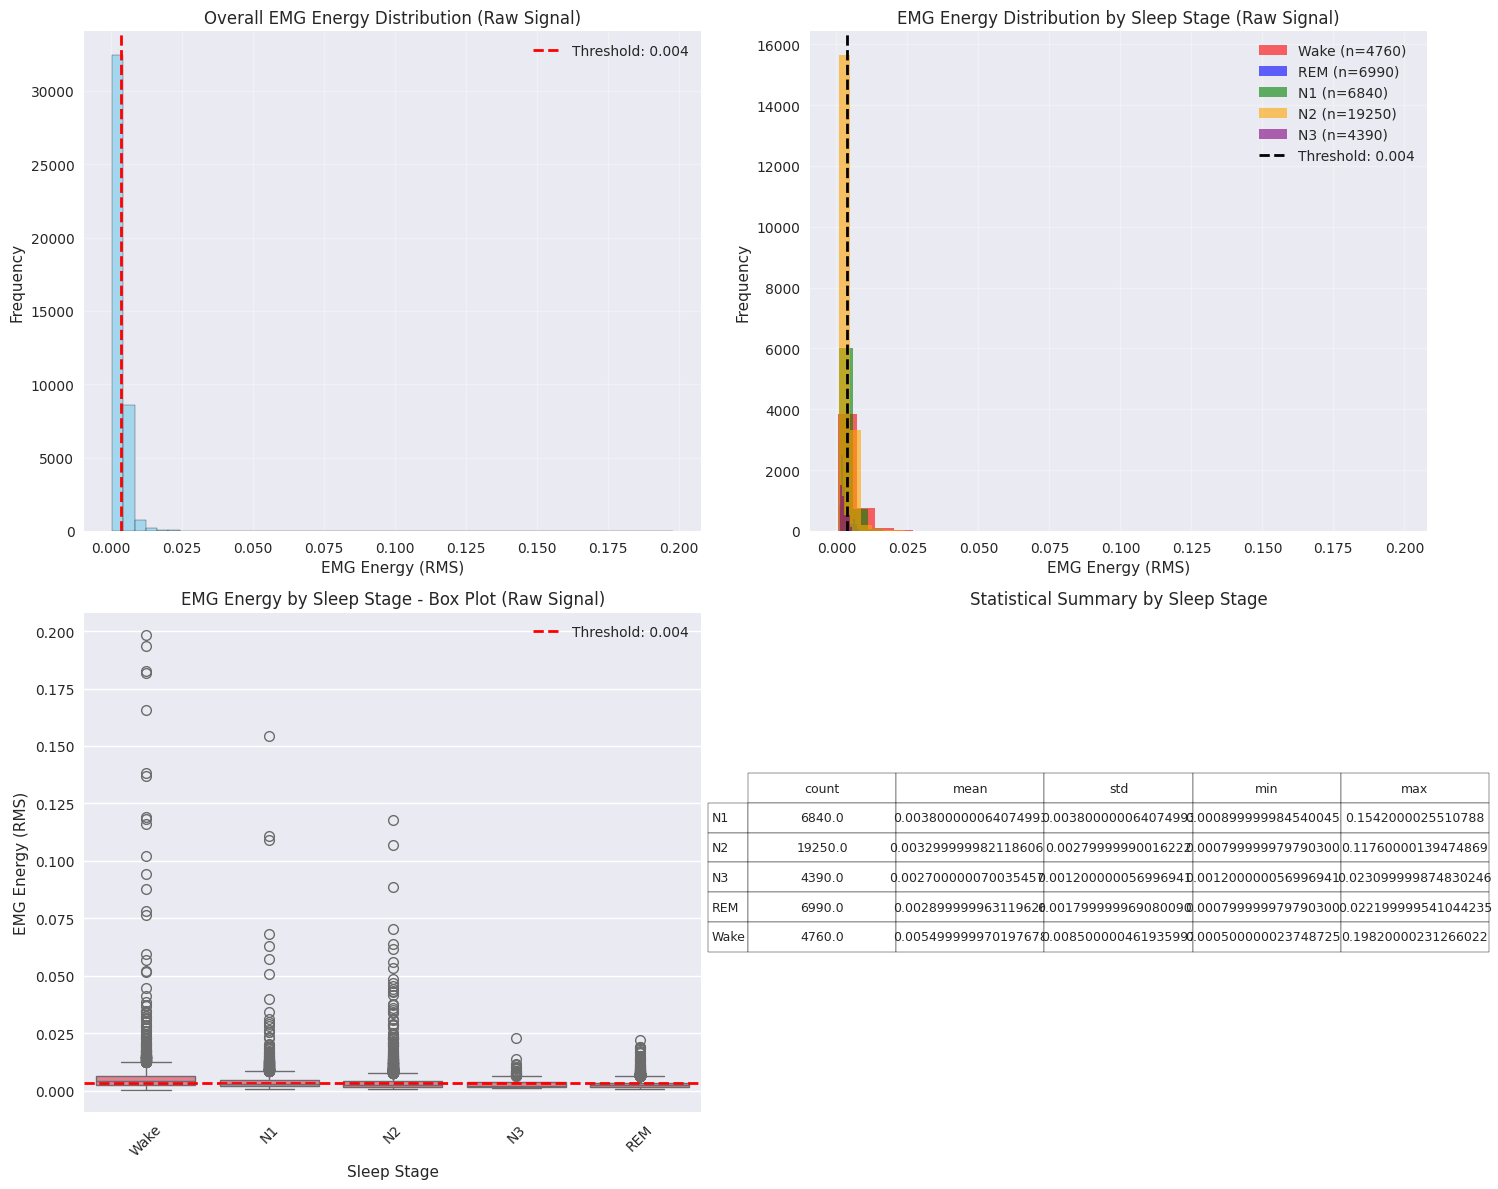


Detailed Statistics by Sleep Stage:
            count    mean     std     min     max
stage_name                                       
N1           6840  0.0038  0.0038  0.0009  0.1542
N2          19250  0.0033  0.0028  0.0008  0.1176
N3           4390  0.0027  0.0012  0.0012  0.0231
REM          6990  0.0029  0.0018  0.0008  0.0222
Wake         4760  0.0055  0.0085  0.0005  0.1982


In [34]:
# Statistical Analysis and Visualization
if len(all_energy_values) > 0:
    # Create DataFrame for analysis
    df = pd.DataFrame({
        'energy': all_energy_values,
        'sleep_stage': all_sleep_stages,
        'stage_name': [sleep_stage_names[int(stage)] for stage in all_sleep_stages]
    })

    # Overall energy distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Overall energy histogram
    axes[0, 0].hist(all_energy_values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    axes[0, 0].set_xlabel('EMG Energy (RMS)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Overall EMG Energy Distribution (Raw Signal)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Energy distribution by sleep stage
    stage_colors = ['red', 'blue', 'green', 'orange', 'purple']
    for stage in range(5):
        stage_data = df[df['sleep_stage'] == stage]['energy']
        if len(stage_data) > 0:
            axes[0, 1].hist(stage_data, bins=30, alpha=0.6, 
                           label=f'{sleep_stage_names[stage]} (n={len(stage_data)})',
                           color=stage_colors[stage])

    axes[0, 1].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    axes[0, 1].set_xlabel('EMG Energy (RMS)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('EMG Energy Distribution by Sleep Stage (Raw Signal)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Box plot by sleep stage
    sns.boxplot(data=df, x='stage_name', y='energy', ax=axes[1, 0])
    axes[1, 0].axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    axes[1, 0].set_xlabel('Sleep Stage')
    axes[1, 0].set_ylabel('EMG Energy (RMS)')
    axes[1, 0].set_title('EMG Energy by Sleep Stage - Box Plot (Raw Signal)')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    # 4. Statistical summary table
    stats_summary = df.groupby('stage_name')['energy'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    table = axes[1, 1].table(cellText=stats_summary.values, 
                            rowLabels=stats_summary.index,
                            colLabels=stats_summary.columns,
                            cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    axes[1, 1].set_title('Statistical Summary by Sleep Stage')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nDetailed Statistics by Sleep Stage:")
    print(stats_summary)

In [35]:
# Generate XML output for each file
print("\n" + "="*60)
print("GENERATING XML OUTPUT FOR EACH FILE")
print("="*60)

os.makedirs(output_dir, exist_ok=True)

# Group data by file
file_groups = {}
for mapping in file_data_mapping:
    file_idx = mapping['file_idx']
    if file_idx not in file_groups:
        file_groups[file_idx] = {
            'file_name': mapping['file_name'],
            'base_name': mapping['base_name'],
            'first_onset': mapping['first_onset'],
            'epochs': []
        }
    file_groups[file_idx]['epochs'].append(mapping['local_epoch_idx'])

# Process each file
file_results = {}
segment_file_results = {}

for file_idx, file_info in file_groups.items():
    file_name = file_info['file_name']
    base_name = file_info['base_name']
    first_onset = file_info['first_onset']
    
    print(f"\nProcessing: {file_name}")
    print(f"  First onset: {first_onset}")
    
    # Collect EMG data for this file
    file_emg_data = []
    for i, mapping in enumerate(file_data_mapping):
        if mapping['file_idx'] == file_idx:
            file_emg_data.append(all_emg_data[i])
    
    if len(file_emg_data) == 0:
        continue
    
    print(f"  Number of epochs: {len(file_emg_data)}")
    
    # Create continuous labels for standard XML
    file_epoch_labels = []
    for epoch_data in file_emg_data:
        energy_values = calculate_emg_energy(epoch_data, segment_length)
        classifications = energy_values < threshold
        
        # Create continuous labels
        y = np.zeros(1500, dtype=np.float32)
        for i, is_low_chin in enumerate(classifications):
            if is_low_chin:
                start_idx = i * segment_length
                end_idx = start_idx + segment_length
                y[start_idx:end_idx] = 1.0
        file_epoch_labels.append(y)
    
    y_continuous = np.concatenate(file_epoch_labels)
    
    # Save standard XML
    xml_filename = f"{base_name}_CHIN.xml"
    xml_save_path = os.path.join(output_dir, xml_filename)
    
    event_count = save_low_chin_xml(
        meas_date=first_onset,
        y_all_epochs=y_continuous,
        sfreq=fs,
        xml_save_path=xml_save_path,
        description="LOW_CHIN_TONE",
        location="EEG-EMG",
        min_duration=1.0
    )
    
    print(f"  Standard XML saved: {xml_filename}")
    print(f"  Events: {event_count}")
    
    # Save segment-wise XML with RMS values
    xml_val_filename = f"{base_name}_CHIN_VAL.xml"
    xml_val_path = os.path.join(output_dir, xml_val_filename)
    
    segment_count = save_low_chin_segments_xml(
        meas_date=first_onset,
        epoch_data_list=file_emg_data,
        sfreq=fs,
        xml_save_path=xml_val_path,
        segment_length=segment_length,
        threshold=threshold
    )
    
    print(f"  Segment XML saved: {xml_val_filename}")
    print(f"  Segments: {segment_count}")

print("\n" + "="*60)
print(f"XML files saved to: {output_dir}")
print(f"Threshold used: {threshold:.4f}")
print("="*60)


GENERATING XML OUTPUT FOR EACH FILE

Processing: SCH-230114R3_M-60-OV-SE.edf
  First onset: 2023-01-14 20:58:49
  Number of epochs: 779
  Standard XML saved: SCH-230114R3_M-60-OV-SE_CHIN.xml
  Events: 287
  Segment XML saved: SCH-230114R3_M-60-OV-SE_CHIN_VAL.xml
  Segments: 7790

Processing: SCH_F_20_OB_231128R4_NO.edf
  First onset: 2023-11-28 22:11:30
  Number of epochs: 894
  Standard XML saved: SCH_F_20_OB_231128R4_NO_CHIN.xml
  Events: 138
  Segment XML saved: SCH_F_20_OB_231128R4_NO_CHIN_VAL.xml
  Segments: 8940

Processing: SCH_F_20_OV_230715R3_MO.edf
  First onset: 2023-07-15 22:12:17
  Number of epochs: 890
  Standard XML saved: SCH_F_20_OV_230715R3_MO_CHIN.xml
  Events: 447
  Segment XML saved: SCH_F_20_OV_230715R3_MO_CHIN_VAL.xml
  Segments: 8900

Processing: SCH_F_40_NW_230511R3_SE.edf
  First onset: 2023-05-11 22:34:32
  Number of epochs: 824
  Standard XML saved: SCH_F_40_NW_230511R3_SE_CHIN.xml
  Events: 405
  Segment XML saved: SCH_F_40_NW_230511R3_SE_CHIN_VAL.xml
  Se

In [36]:
# Final Summary
print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY - Version 2 (Raw EDF)")
print("="*60)

print(f"\nData Loading Method:")
print(f"  - Direct EDF loading using sleep_stage modules")
print(f"  - Raw signal processing without normalization")
print(f"  - Channel mapping based on sleep_score.py")

print(f"\nDataset Information:")
print(f"  Total files processed: {len(file_groups)}")
print(f"  Total 30-second epochs: {len(all_emg_data)}")
print(f"  Total 3-second segments: {len(all_energy_values)}")

if len(rem_energy_values) > 0:
    print(f"\nThreshold Calculation:")
    print(f"  Based on REM stage statistics")
    print(f"  REM segments used: {len(rem_energy_values)}")
    print(f"  Threshold value: {threshold:.4f}")
    print(f"  Method: {threshold_percentile}th percentile of REM energy values")

# Classification results
if len(all_energy_values) > 0:
    low_chin_classifications = all_energy_values < threshold
    low_chin_count = np.sum(low_chin_classifications)
    low_chin_percentage = (low_chin_count / len(all_energy_values)) * 100
    
    print(f"\nLow Chin Tone Detection Results:")
    print(f"  Total segments analyzed: {len(all_energy_values)}")
    print(f"  Low chin tone detected: {low_chin_count} ({low_chin_percentage:.1f}%)")
    print(f"  Normal chin tone: {len(all_energy_values) - low_chin_count} ({100 - low_chin_percentage:.1f}%)")
    
    # Breakdown by sleep stage
    print(f"\nLow Chin Tone by Sleep Stage:")
    for stage in range(5):
        stage_mask = all_sleep_stages == stage
        if np.any(stage_mask):
            stage_total = np.sum(stage_mask)
            stage_low_chin = np.sum(low_chin_classifications[stage_mask])
            stage_percentage = (stage_low_chin / stage_total) * 100 if stage_total > 0 else 0
            print(f"  {sleep_stage_names[stage]:>5}: {stage_low_chin:>4}/{stage_total:<4} ({stage_percentage:>5.1f}%)")

print(f"\nXML Output Summary:")
print(f"  Output directory: {output_dir}")
print(f"  Two types of XML files generated:")
print(f"    1. [filename]_CHIN.xml - Continuous low chin events")
print(f"    2. [filename]_CHIN_VAL.xml - 3-second segments with RMS values")
print(f"  Description format: TYPE_RMS (TYPE=LOW/HIGH, RMS=energy value)")

print("\n" + "="*60)
print("Analysis completed successfully!")
print("Version 2: Using raw EDF signals without normalization")
print("="*60)


FINAL ANALYSIS SUMMARY - Version 2 (Raw EDF)

Data Loading Method:
  - Direct EDF loading using sleep_stage modules
  - Raw signal processing without normalization
  - Channel mapping based on sleep_score.py

Dataset Information:
  Total files processed: 5
  Total 30-second epochs: 4223
  Total 3-second segments: 42230

Threshold Calculation:
  Based on REM stage statistics
  REM segments used: 6990
  Threshold value: 0.0036
  Method: 75th percentile of REM energy values

Low Chin Tone Detection Results:
  Total segments analyzed: 42230
  Low chin tone detected: 27601 (65.4%)
  Normal chin tone: 14629 (34.6%)

Low Chin Tone by Sleep Stage:
   Wake: 1897/4760 ( 39.9%)
    REM: 5242/6990 ( 75.0%)
     N1: 4182/6840 ( 61.1%)
     N2: 13002/19250 ( 67.5%)
     N3: 3278/4390 ( 74.7%)

XML Output Summary:
  Output directory: /home/honeynaps/data/shared/integrate/output
  Two types of XML files generated:
    1. [filename]_CHIN.xml - Continuous low chin events
    2. [filename]_CHIN_VAL.xml 